In [43]:
import polars as pl


schema = pl.Schema({"RoundTrip":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})

fabrics_spin = pl.read_csv("../output/MXLFabrics+Host2Host+SHM+OneWay+Spin.csv", schema=schema);
fabrics_wait = pl.read_csv("../output/MXLFabrics+Host2Host+SHM+OneWay+Wait.csv", schema=schema);
mxlshm_wait = pl.read_csv("../output/MXLSHM+OneWay+Wait.csv", schema=schema);
mxlshm_spin = pl.read_csv("../output/MXLSHM+OneWay+Spin.csv", schema=schema);

In [44]:
latency_fabrics_spin = (fabrics_spin.select(pl.col("RxTime")) - fabrics_spin.select(pl.col("TxTime")))/1000000
latency_fabrics_wait = (fabrics_wait.select(pl.col("RxTime")) - fabrics_wait.select(pl.col("TxTime")))/1000000
latency_mxlshm_spin = (mxlshm_spin.select(pl.col("RxTime")) - mxlshm_spin.select(pl.col("TxTime")))/1000000
latency_mxlshm_wait = (mxlshm_wait.select(pl.col("RxTime")) - mxlshm_wait.select(pl.col("TxTime")))/1000000

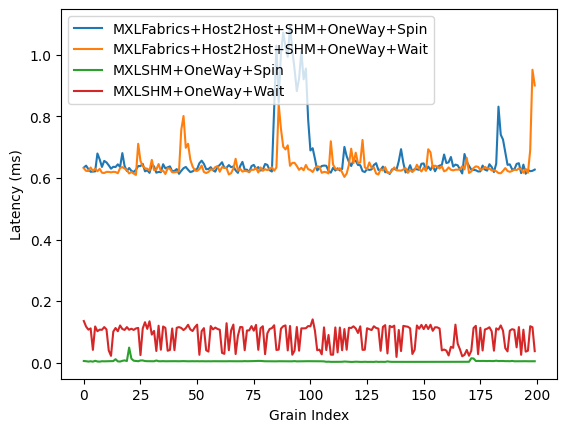

In [45]:
import matplotlib.pyplot as plt

plt.plot(latency_fabrics_spin, label="MXLFabrics+Host2Host+SHM+OneWay+Spin")
plt.plot(latency_fabrics_wait, label="MXLFabrics+Host2Host+SHM+OneWay+Wait")
plt.plot(latency_mxlshm_spin, label="MXLSHM+OneWay+Spin")
plt.plot(latency_mxlshm_wait, label="MXLSHM+OneWay+Wait")
plt.ylabel("Latency (ms)")
plt.xlabel("Grain Index")
plt.legend()
plt.show()